<a href="https://colab.research.google.com/github/ShashantSahu/Credit-Card-Fraud-Detection.ipynb/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Credit Card Fraud Detection

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [7]:
df = pd.read_csv("/content/creditcard (1).csv")

In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63472 entries, 0 to 63471
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    63472 non-null  int64  
 1   V1      63472 non-null  float64
 2   V2      63472 non-null  float64
 3   V3      63472 non-null  float64
 4   V4      63472 non-null  float64
 5   V5      63472 non-null  float64
 6   V6      63472 non-null  float64
 7   V7      63472 non-null  float64
 8   V8      63472 non-null  float64
 9   V9      63472 non-null  float64
 10  V10     63471 non-null  float64
 11  V11     63471 non-null  float64
 12  V12     63471 non-null  float64
 13  V13     63471 non-null  float64
 14  V14     63471 non-null  float64
 15  V15     63471 non-null  float64
 16  V16     63471 non-null  float64
 17  V17     63471 non-null  float64
 18  V18     63471 non-null  float64
 19  V19     63471 non-null  float64
 20  V20     63471 non-null  float64
 21  V21     63471 non-null  float64
 22

In [17]:
# Drop rows where the 'Class' column is NaN
df.dropna(subset=['Class'], inplace=True)

# Verify that NaNs in 'Class' are gone and check new info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 63471 entries, 0 to 63470
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    63471 non-null  float64
 1   V1      63471 non-null  float64
 2   V2      63471 non-null  float64
 3   V3      63471 non-null  float64
 4   V4      63471 non-null  float64
 5   V5      63471 non-null  float64
 6   V6      63471 non-null  float64
 7   V7      63471 non-null  float64
 8   V8      63471 non-null  float64
 9   V9      63471 non-null  float64
 10  V10     63471 non-null  float64
 11  V11     63471 non-null  float64
 12  V12     63471 non-null  float64
 13  V13     63471 non-null  float64
 14  V14     63471 non-null  float64
 15  V15     63471 non-null  float64
 16  V16     63471 non-null  float64
 17  V17     63471 non-null  float64
 18  V18     63471 non-null  float64
 19  V19     63471 non-null  float64
 20  V20     63471 non-null  float64
 21  V21     63471 non-null  float64
 22  V22

In [10]:
df['Class'].value_counts()

,count
Class,
0.0,63306
1.0,165


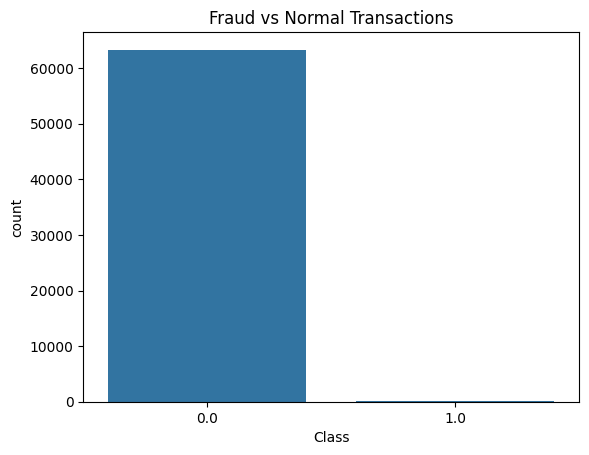

In [11]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [19]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_res))

After SMOTE: [50648 50648]


In [24]:
lr = LogisticRegression()

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)

In [25]:
print("Logistic Regression Result:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Result:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     12658
         1.0       0.12      0.95      0.21        37

    accuracy                           0.98     12695
   macro avg       0.56      0.96      0.60     12695
weighted avg       1.00      0.98      0.99     12695



In [27]:
rf = RandomForestClassifier(n_estimators=50) # Reduced n_estimators

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

In [28]:
print("Random Forest Result:")
print(classification_report(y_test.astype(int), y_pred_rf.astype(int)))

Random Forest Result:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12658
           1       1.00      0.81      0.90        37

    accuracy                           1.00     12695
   macro avg       1.00      0.91      0.95     12695
weighted avg       1.00      1.00      1.00     12695



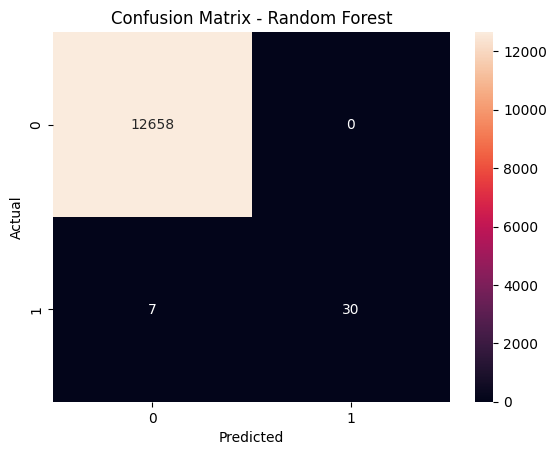

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()